# DX 702 (Mod 6): Homework Reflections, 9 - 12

## <font color='plum'> ANSWERS & RESPONSES IN THIS COLOR

In [29]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima_process import ArmaProcess
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Helper Functions

In [ ]:
def generate_data(n):
    """Generate synthetic data with high correlation between X and Z, and Y as a linear combination."""
    Z = np.random.normal(0, 1, n)
    X = Z + np.random.normal(0, 0.01, n)  # High correlation with Z
    Y = 1.5 * X + 2.3 * Z + np.random.normal(0, 1, n)
    return X, Z, Y


def estimate_coef(X, Z, Y):
    """
    Estimates the coefficient and its standard error for the first predictor in a linear regression.

    Fits an OLS model using the predictors X and Z to predict the target variable Y. It returns the estimated coefficient and standard error
    for the first predictor (X), assuming X and Z are both included as independent variables.

    Parameters:
        X -  array-like
            The primary predictor variable.
        Z - array-like
            The secondary predictor variable (used as a control or additional regressor).
        Y - array-like
            The dependent or response variable.

    Returns:
        A tuple containing
        - coef (float): Estimated coefficient for X.
        - std_err (float): Standard error of the estimated coefficient for X.
    """

    XZ = np.column_stack((X, Z))
    XZ = sm.add_constant(XZ)
    model = sm.OLS(Y, XZ).fit()
    return model.params[1], model.bse[1]  # Coefficient and standard error of X


# Full simulation to estimate true standard deviation of X's coefficient
def full_simulation(n, runs=1000):
    coefs = []
    for _ in range(runs):
        X, Z, Y = generate_data(n)
        coef, _ = estimate_coef(X, Z, Y)
        coefs.append(coef)
    return np.std(coefs)


In [31]:

# Bootstrap estimation of standard deviation of X's coefficient
def bootstrap_std(X, Z, Y, runs=1000):
    """
    Estimates the standard deviation of a coefficient using bootstrap resampling.

    Performs bootstrap resampling on the input datasets (X, Z, Y)
    to estimate the standard deviation of a coefficient obtained
    from the `estimate_coef` function. It repeatedly samples with replacement
    from the data, computes the coefficient for each resample, and returns the
    standard deviation of these coefficients.

    Parameters:
        X : array-like. The first input feature array.
        Z : array-like. The second input feature array.
        Y : array-like. The target variable array.
        runs : int, optional (default=1000). The number of bootstrap iterations to perform.

    Returns:
        float: The standard deviation of the estimated coefficients across bootstrap samples.
    """

    coefs = []
    for _ in range(runs):
        indices = resample(np.arange(len(X)))
        Xb, Zb, Yb = X[indices], Z[indices], Y[indices]
        coef, _ = estimate_coef(Xb, Zb, Yb)
        coefs.append(coef)
    return np.std(coefs)


# My Random Notes

`statsmodels.api` and `statsmodels.formula.api` are **two different interfaces** to the same underlying statistical modeling library, but they serve different purposes and have different workflows.


### Differences

#### 1. **`statsmodels.api`**
- **Manual interface**: You manually prepare your design matrices (`X` and `y`).
- **More control**: You explicitly handle preprocessing like encoding categorical variables, adding intercepts, etc.
- **Used for**: Advanced users who want full control over the modeling pipeline.

**Example:**
```python
import statsmodels.api as sm

X = df[['x1', 'x2']]
X = sm.add_constant(X)  # manually add intercept
y = df['y']

model = sm.OLS(y, X).fit()
```

---

#### 2. **`statsmodels.formula.api`**
- **Formula interface**: Uses R-style formulas to specify models.
- **Automatic handling**: Automatically encodes categorical variables, adds intercepts, and builds design matrices.
- **Used for**: Quick and readable modeling, especially for statistical analysis and ANOVA.

**Example:**
```python
import statsmodels.formula.api as smf

model = smf.ols('y ~ x1 + C(group)', data=df).fit()
```

---

### Summary

| Feature                     | `statsmodels.api`         | `statsmodels.formula.api`     |
|----------------------------|---------------------------|-------------------------------|
| Input format               | Manual (`X`, `y`)         | Formula string (`'y ~ x1 + x2'`) |
| Categorical handling       | Manual (e.g., `pd.get_dummies`) | Automatic (`C(var)`)         |
| Intercept                  | Must add manually         | Added automatically           |
| Flexibility                | High                      | Moderate                      |
| Readability                | Moderate                  | High                          |
| Best for                   | Custom pipelines          | Quick statistical modeling    |

---


# Homework Reflection 9

## HW9.Q1
#### Write a simulation to estimate the <font color='cyan'>standard deviation of the coefficient</font> when there is <font color='cyan'>heteroskedasticity. </font> 
#### Compare these standard errors to those found via `statsmodels OLS` or a similar linear regression model.


In [32]:
np.random.seed(42)

# Simulation parameters
n               = 100  # number of observations
coeff_true       = 2.0  # true coefficient
num_simulations = 1000  


coeff_estimates = []

#simulating 1000 datasets with heteroskedastic errors and estimating coefficient of X in each dataset to compute STDVN  f  estimated coefficients
for simulation in range(num_simulations):
    x       = np.random.normal(0, 1, n) # Generates n values for independent variable x from  standard normal distribution.
  

 # Create heteroskedastic errors: the standard deviation of the error increases with the magnitude of x.  Simulates a situation where variance is not constant.
    errors  = np.random.normal(0, 1 + 0.5 * np.abs(x))


   # Constructs the dependent variable y using the linear model: y = βx + error.
    y       = (coeff_true * x) + errors

    X       = sm.add_constant(x) # Add  column of ones to x to include an intercept in the regression model.
    model   = sm.OLS(y, X).fit() #Fit OLS
    coeff_estimates.append(model.params[1]) #Extract estimated slope coefficient and store


# stdvn of estimated coefficients across all simulations. 
# EMPIRICAL ESTIMATE of standard ERROR under heteroskedasticity
simulated_std = np.std(coeff_estimates)


In [ ]:

############# Single OLS Fit for Comparison ##########

# Generate new dataset and fit OLS model to it.
x       = np.random.normal(0, 1, n)
errors  = np.random.normal(0, 1 + 0.5 * np.abs(x)) # inject heteroskedastic errors

y       = coeff_true * x + errors
X       = sm.add_constant(x)

model           = sm.OLS(y, X).fit()
ols_std_error   = model.bse[1] # Extract standard error of slope coefficient from statsmodels.


print(f"Simulated standard deviation of coefficient: {simulated_std:.4f}")
print(f"OLS standard error of coefficient: {ols_std_error:.4f}")


Simulated standard deviation of coefficient: 0.1892
OLS standard error of coefficient: 0.1731


<font color='plum'>
'Simulated Standard Error'  = standard deviation of coefficient estimates from  bootstrap simulation, a.k.a. the true STDVN of coefficient estimate under heteroskedasticity.<br>


OLS standard error assumes *homoskedasticity* (constant variance of errors); consequently, when heteroskedasticity is present, it tends to <u>underestimate</u> the true STDVN .

## HW9.Q2. 
#### Write some code that will use a simulation to estimate the standard deviation of the coefficient when <font color='cyan'>errors are highly correlated / non-independent.</font>
#### Compare these standard errors to those found via `statsmodels OLS` or a similar linear regression model.


In [34]:
import numpy as np
import statsmodels.api as sm

np.random.seed(42)

# Simulation parameters
n               = 100  # number of observations
beta_true       = 2.0  # true coefficient
num_simulations = 1000

#  estimated coefficients
beta_estimates = []

for _ in range(num_simulations):
    x = np.random.normal(0, 1, n)

    # Generate correlated errors using cumulative sum (random walk)
    raw_errors  = np.random.normal(0, 1, n)
    errors      = np.cumsum(raw_errors)  # inject strong autocorrelation

    y = (beta_true * x) + errors

    X       = sm.add_constant(x)
    model   = sm.OLS(y, X).fit()
    beta_estimates.append(model.params[1])

# STDVN of estimated coefficients
simulated_std = np.std(beta_estimates)

# Compare with standard error from a single OLS fit
x           = np.random.normal(0, 1, n)
raw_errors  = np.random.normal(0, 1, n)
errors      = np.cumsum(raw_errors)

y               = (beta_true * x) + errors
X               = sm.add_constant(x)
model           = sm.OLS(y, X).fit()
ols_std_error   = model.bse[1]

print(f"Simulated standard deviation of coefficient: {simulated_std:.4f}")
print(f"OLS standard error of coefficient: {ols_std_error:.4f}")



Simulated standard deviation of coefficient: 0.4217
OLS standard error of coefficient: 0.4510


<font color='plum'>
The standard error reported by ``statsmodels.OLS`` is slightly higher than the simulated standard deviation, which is expected because autocorrelation violates the OLS assumption of independent errors. This can lead to inflated standard errors and less reliable inference if not corrected.

## HW9.Q3. 
#### Show that if the correlation between coefficients is high enough, then the estimated standard deviation of the coefficient, using bootstrap errors,  might not match that found by a full simulation of the Data Generating Process.  

(This can be fixed if you have a huge amount of data for the bootstrap simulation.)

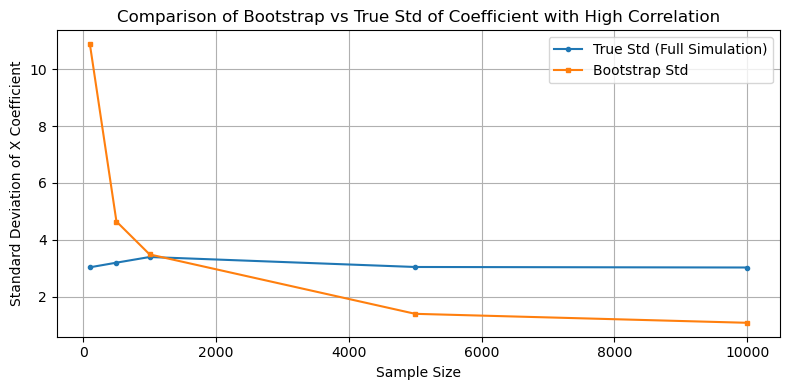

In [35]:
np.random.seed(42)

# Compare for different sample sizes
sample_sizes    = [100, 500, 1000, 5000, 10000]
true_stds       = []
bootstrap_stds  = []

for n in sample_sizes:
    X, Z, Y     = generate_data(n)
    true_std    = full_simulation(n=1000, runs=200)  # Use fixed n=1000 for true std
    boot_std    = bootstrap_std(X, Z, Y, runs=200)
    true_stds.append(true_std)
    bootstrap_stds.append(boot_std)

# Plotting the comparison
plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, true_stds, label='True Std (Full Simulation)', marker='o', markersize=3)
plt.plot(sample_sizes, bootstrap_stds, label='Bootstrap Std', marker='s', markersize=3)
plt.xlabel('Sample Size')
plt.ylabel('Standard Deviation of X Coefficient')
plt.title('Comparison of Bootstrap vs True Std of Coefficient with High Correlation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font color='plum'>

- When X and Z are highly correlated, the bootstrap method <font color='salmon'>*underestimates*</font> the standard deviation of the coefficient, especially at smaller sample sizes.

- As the sample size increases, the bootstrap estimate <font color='salmon'>*converges*</font> toward the true standard deviation.

- Bootstrapping can be misleading in the presence of multicollinearity unless the dataset is very large.

------------------

# Homework Reflection 11

## HW11.Q1. 
#### Construct a dataset for an <font color = 'cyan'>event study</font> where the value, derivative, and second derivative of a trend all change discontinuously (suddenly) after an event.

#### Build a model that tries to decide whether the event is real (has a nonzero effect) using:
- (a) only the value,
- (b) the value, derivative, and second derivative.

#### Which of these models is better at detecting and/or quantifying the impact of the event?  (What might "better" mean here?)

Model_a summary:
                            OLS Regression Results                            
Dep. Variable:                  event   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     246.8
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           1.21e-36
Time:                        22:15:22   Log-Likelihood:                -64.226
No. Observations:                 200   AIC:                             132.5
Df Residuals:                     198   BIC:                             139.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1434      0.033   

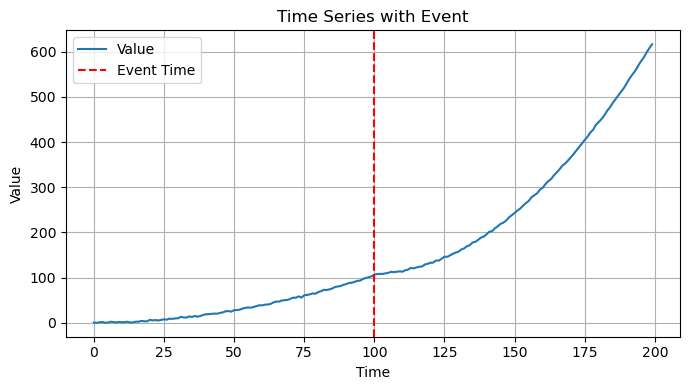

In [36]:
np.random.seed(42)

# Generate time series data
n           = 200
event_time  = 100
time        = np.arange(n)

# Pre-event trend: quadratic
pre_event   = (0.05 * time[:event_time]) + (0.01 * time[:event_time]**2)

# Post-event trend: sudden change in value, slope, and curvature
post_event = (
    pre_event[-1] + 5 +  # jump in value
    0.2 * (time[event_time:] - event_time) +  # change in slope
    0.05 * (time[event_time:] - event_time)**2  # change in curvature
)

# Combine and add noise
trend = np.concatenate([pre_event, post_event])
noise = np.random.normal(0, 1, n)
value = trend + noise
    
# Compute derivative and second derivative 
derivative          = np.gradient(value)
second_derivative   = np.gradient(derivative)

#  stupidass dataset 
df = pd.DataFrame({
    'time': time,
    'value': value,
    'deriv': derivative,
    'second_deriv': second_derivative,
    'event': (time >= event_time).astype(int)
})

# Model_a: using only value
X_a     = sm.add_constant(df[['value']])
model_a = sm.OLS(df['event'], X_a).fit()

# Model_b: using value, derivative, and second derivative
X_b     = sm.add_constant(df[['value', 'deriv', 'second_deriv']])
model_b = sm.OLS(df['event'], X_b).fit()

print(f"Model_a summary:\n{model_a.summary()}")
print("-------------------------------------------------------------------------------------\n")

print(f"\nModel_b summary:\n{model_b.summary()}")

# Compare effectiveness
print("\nR-squared values:")
print(f"Model_a : {model_a.rsquared:.4f}")
print(f"Model_b : {model_b.rsquared:.4f}")

# time series and event plot
plt.figure(figsize=(7, 4))
plt.plot(df['time'], df['value'], label = 'Value')
plt.axvline(event_time, color = 'red', linestyle='--', label = 'Event Time')
plt.title("Time Series with Event")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



<font color='plum'>

##### Model_A 
- predicts whether an event occurred (non-zero effect) based solely on the observed value. 
- R-squared =  0.5548

##### Model_B 
- predicts whether an event occurred based on the observed value, rate of change and acceleration. 
- R-squared =  0.5603. 
- higher R-squared  explains more variance in detecting the event; while first and second derivative of coefficients might have some explanatory power, they're not statistically significant. 


## HW11.Q2. 
#### Construct a dataset in which there are <font color = 'cyan'>three groups whose values each increase discontinuously (suddenly) by the same amount at a shared event</font>; they change in parallel over time, but they have different starting values.  
#### Create a model that <font color='cyan'>combines group fixed effects</font> with an <font color='cyan'>event study</font>, as suggested in the online reading.
#### Explain what you did, how the model works, and how it accounts for both baseline differences and the common event effect.

In [37]:

np.random.seed(42)

n_timepoints    = 20
groups          = ['A', 'B', 'C']
event_time      = 10
event_effect    = 5

# Create dataset
data = []
for group in groups:
    baseline = {'A': 10, 'B': 20, 'C': 30}[group]
    for t in range(n_timepoints):
        value = baseline + t  # linear trend
        if t >= event_time:
            value += event_effect  # apply event effect
        data.append({'group': group, 'time': t, 'value': value})

df = pd.DataFrame(data)


In [38]:

#  event indicator
df['post_event'] = (df['time'] >= event_time).astype(int)

# Fit model with group fixed effects and event indicator
model = smf.ols('value ~ C(group) + post_event', data = df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     278.1
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           1.35e-33
Time:                        22:15:23   Log-Likelihood:                -148.44
No. Observations:                  60   AIC:                             304.9
Df Residuals:                      56   BIC:                             313.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        14.5000      0.768     18.889

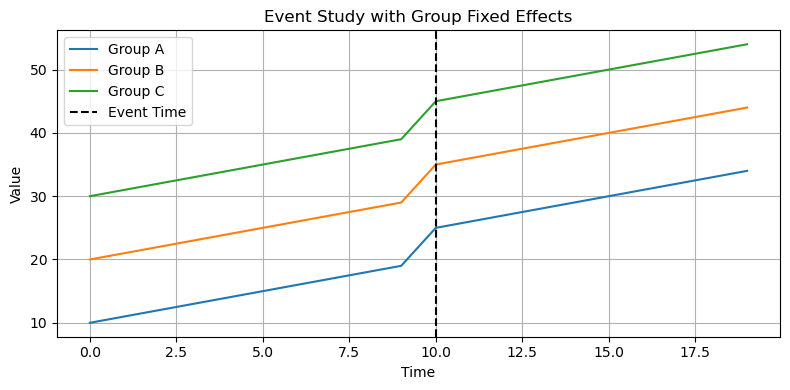

In [39]:

plt.figure(figsize=(8, 4))
for group in groups:
    subset = df[df['group'] == group]
    plt.plot(subset['time'], subset['value'], label=f'Group {group}')
plt.axvline(event_time, color='black', linestyle='--', label='Event Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Event Study with Group Fixed Effects')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<font color = 'plum'> A, B, and C each follow a linear trend over time and differ only in their baseline levels. At shared event time `t = 10`, all groups experience a sudden increase of +5 units.


Yours truly fitted a linear regression model with:
- Group fixed effects: `C(group)` (the baseline differences between groups).
- Event indicator: `post_event` = 1 after the event and 0 before.


The model  `value ~ C(group) + post_event` estimates:
- a baseline intercept (Group A before the event),
- Group B and C effects relative to Group A,
- a common event effect across all groups.

*Fixed effects* control for group-specific baselines, isolating the effect of the event. The *event indicator* captures the common shift across all groups.

-------------------------------

# Homework Reflection 12

## HW12.Q1. 
#### Construct a dataset in which prior trends do not hold; demonstrate how this produces an inaccurate Differences-in-Differences (DiD) estimate of the effect and explain why it's higher or lower than the actual effect.

Construct dataset where parallel trends fail; explain why DID estimate is biased.

#### <font color='plum'> In other words, demonstrate how violating the parallel trends assumption in a DiD study can lead to a misleading estimate of the effect.

In [40]:
np.random.seed(42)

# Samples per group per period
n = 100

# Define groups and periods
groups = ['Control', 'Treatment']
periods = ['Pre', 'Event', 'Post']

# list of dictionaries to hold the data
data = []

for group in groups:
    for period in periods:
        if group == 'Control':
            # Control group: slight upward trend
            base = 50
            trend = {'Pre': 0, 'Event': 0.5, 'Post': 1.0}
        else:
            # Treatment group: stronger upward trend
            base = 40
            trend = {'Pre': 0, 'Event': 3.0, 'Post': 6.0}
        
        values = np.random.normal(base + trend[period], 5, n)
        for value in values:
            data.append({'group': group, 'period': period, 'value': value})


df = pd.DataFrame(data)
df 


,group,period,value
0,Control,Pre,52.483571
1,Control,Pre,49.308678
2,Control,Pre,53.238443
3,Control,Pre,57.615149
4,Control,Pre,48.829233
...,...,...,...
595,Treatment,Post,43.449918
596,Treatment,Post,44.650625
597,Treatment,Post,41.106181
598,Treatment,Post,43.778534


In [41]:

#  binary indicators for treatment group and post-treatment period
df['treatment'] = (df['group'] == 'Treatment').astype(int)
df['post']      = (df['period'] == 'Post').astype(int)

# Interaction term: treatment * post
df['did']       = df['treatment'] * df['post']

#  DiD regression
model           = smf.ols('value ~ treatment + post + did', data = df).fit()

print(model.summary())
 

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     134.1
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           2.16e-66
Time:                        22:15:23   Log-Likelihood:                -1803.8
No. Observations:                 600   AIC:                             3616.
Df Residuals:                     596   BIC:                             3633.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     50.0461      0.347    144.234      0.0

<font color='plum'>The DiD estimate of treatment effect is +2.52. But, since the treatment group already had a stronger upward trend before the intervention, this estimate overstates the true causal effect.

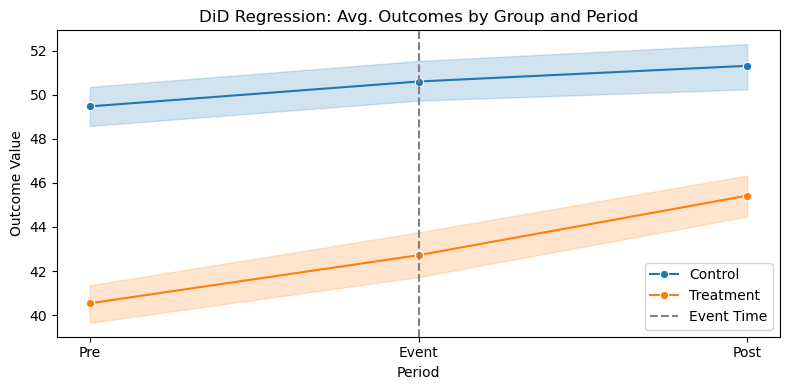

In [42]:

# setting period order for x-axis
df['period'] = pd.Categorical(df['period'], categories=['Pre', 'Event', 'Post'], ordered=True)

#  average outcomes by group and period
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x='period', y='value', hue='group', marker='o')
plt.axvline(x=1, color='gray', linestyle='--', label='Event Time')
plt.title('DiD Regression: Avg. Outcomes by Group and Period')
plt.ylabel('Outcome Value')
plt.xlabel('Period')
plt.legend()
plt.tight_layout()
plt.show()


-------------------------------------